In [1]:
import numpy as np
from forward_propagater import *
from input_writer import glowDischargeConfigs

import matplotlib.pyplot as plt
%matplotlib inline

prefix = '10000K'

In [2]:
outputFilename = "./torch1d/output-Biagi_v7.1+step.%s.dat" % prefix
output = bolsigOutput(outputFilename)
Te0 = output.outputs[3].data[:,1]
qe = 1.60217663e-19
kB = 1.380649e-23
NA = 6.0221408e23
# NA = 1.0
Te0 *= qe / 1.5 / kB
print("ElectronVolt unit used here: %.5E (eV/K)" % (qe / 1.5 / kB))

dataType = output.typeDictS2I['C2']
rateExcite0 = NA * output.outputs[dataType].data[:,1]
dataType = output.typeDictS2I['C5']
rateIon0 = NA * output.outputs[dataType].data[:,1]
dataType = output.typeDictS2I['C6']
rateStepIon0 = NA * output.outputs[dataType].data[:,1]

ElectronVolt unit used here: 7.73635E+03 (eV/K)


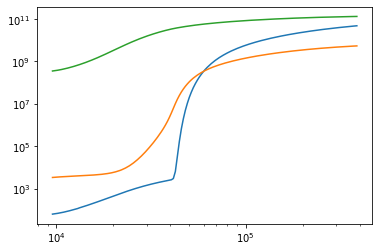

In [58]:
plt.figure(1)
plt.loglog(Te0, rateIon0)
plt.loglog(Te0, rateExcite0)
plt.loglog(Te0, rateStepIon0)

np.savetxt('./torch1d/ionization.%s.txt' % prefix, np.array([Te0, rateIon0]).T)
np.savetxt('./torch1d/excitation.%s.txt' % prefix, np.array([Te0, rateExcite0]).T)
np.savetxt('./torch1d/step-ionization.%s.txt' % prefix, np.array([Te0, rateStepIon0]).T)

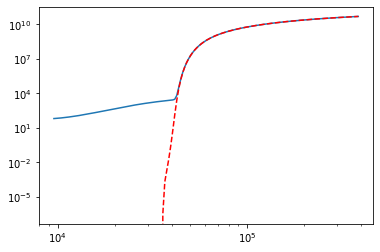

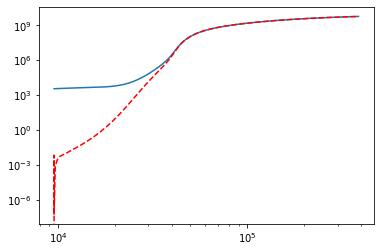

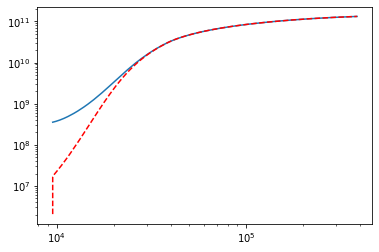

In [3]:
rateIon1 = np.loadtxt('./torch1d/ionization.5000K.txt')
rateExcite1 = np.loadtxt('./torch1d/excitation.5000K.txt')
rateStepIon1 = np.loadtxt('./torch1d/step-ionization.5000K.txt')

plt.figure(1)
plt.loglog(Te0, rateIon0,'-')
plt.loglog(Te0, rateIon1[:,1],'--r')
plt.figure(2)
plt.loglog(Te0, rateExcite0,'-')
plt.loglog(Te0, rateExcite1[:,1],'--r')
plt.figure(3)
plt.loglog(Te0, rateStepIon0,'-')
plt.loglog(Te0, rateStepIon1[:,1],'--r')


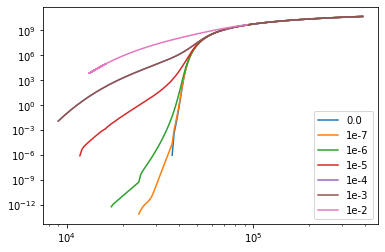

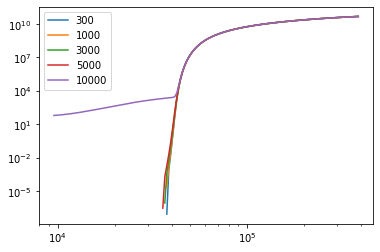

In [4]:
rateIon = [np.loadtxt('./torch1d/ionization.3000K.txt')]
for k in range(6):
    prefix = '3000K.ion1e-%d' % (7-k)
    rateIon += [np.loadtxt('./torch1d/ionization.%s.txt' % prefix)]

labels = ['0.0', '1e-7','1e-6', '1e-5', '1e-4', '1e-3', '1e-2']
    
plt.figure(1)
for k, rateIonK in enumerate(rateIon):
    idx = (rateIonK[:,1] > 0.0)
    plt.loglog(rateIonK[idx,0], rateIonK[idx,1], '-', label=labels[k])
#     plt.loglog(rateIonK[:,0], rateIonK[:,1], '-', label=labels[k])
plt.legend()

temps = ['300', '1000', '3000', '5000', '10000']
rateIon = []
for k in range(len(temps)):
    rateIon += [np.loadtxt('./torch1d/ionization.%sK.txt' % temps[k])]
    
plt.figure(2)
for k, rateIonK in enumerate(rateIon):
    idx = (rateIonK[:,1] > 0.0)
    plt.loglog(rateIonK[idx,0], rateIonK[idx,1], '-', label=temps[k])
#     plt.loglog(rateIonK[:,0], rateIonK[:,1], '-', label=labels[k])
plt.legend()

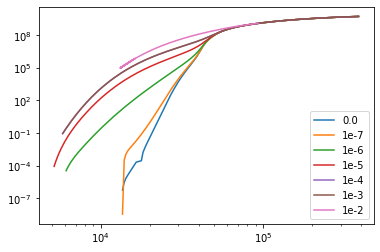

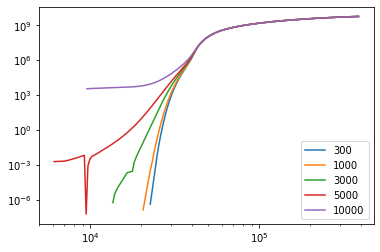

In [61]:
rateExcite = [np.loadtxt('./torch1d/excitation.3000K.txt')]
for k in range(6):
    prefix = '3000K.ion1e-%d' % (7-k)
    rateExcite += [np.loadtxt('./torch1d/excitation.%s.txt' % prefix)]

plt.figure(1)
for k, rateExciteK in enumerate(rateExcite):
    idx = (rateExciteK[:,1] > 0.0)
    plt.loglog(rateExciteK[idx,0], rateExciteK[idx,1], '-', label=labels[k])
#     plt.loglog(rateExciteK[:,0], rateExciteK[:,1], '-', label=labels[k])
plt.legend()

rateExcite = []
for k in range(len(temps)):
    rateExcite += [np.loadtxt('./torch1d/excitation.%sK.txt' % temps[k])]
    
plt.figure(2)
for k, rateExciteK in enumerate(rateExcite):
    idx = (rateExciteK[:,1] > 0.0)
    plt.loglog(rateExciteK[idx,0], rateExciteK[idx,1], '-', label=temps[k])
plt.legend()

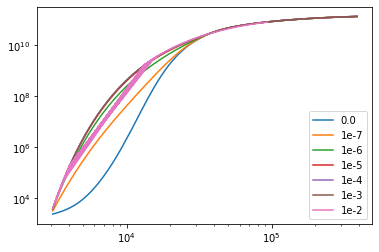

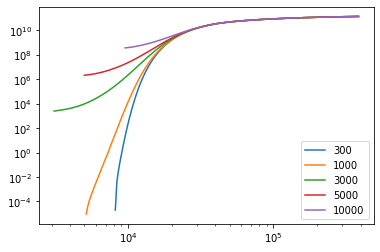

In [62]:
rateStepIon = [np.loadtxt('./torch1d/step-ionization.3000K.txt')]
for k in range(6):
    prefix = '3000K.ion1e-%d' % (7-k)
    rateStepIon += [np.loadtxt('./torch1d/step-ionization.%s.txt' % prefix)]

plt.figure(1)
for k, rateStepIonK in enumerate(rateStepIon):
    idx = (rateStepIonK[:,1] > 0.0)
    plt.loglog(rateStepIonK[idx,0], rateStepIonK[idx,1], '-', label=labels[k])
#     plt.loglog(rateStepIonK[:,0], rateStepIonK[:,1], '-', label=labels[k])
plt.legend()

rateStepIon = []
for k in range(len(temps)):
    rateStepIon += [np.loadtxt('./torch1d/step-ionization.%sK.txt' % temps[k])]
    
plt.figure(2)
for k, rateStepIonK in enumerate(rateStepIon):
    idx = (rateStepIonK[:,1] > 0.0)
    plt.loglog(rateStepIonK[idx,0], rateStepIonK[idx,1], '-', label=temps[k])
plt.legend()